Pipeline for sentiment analysis local XAI benchmark  
https://github.com/mmschlk/shapiq/blob/main/examples/language/plot_sentiment_analysis.py 

In [3]:
import os

# Prevent OpenMP/MKL thread conflicts with PyTorch backend
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

import shapiq
from shapiq_games.benchmark import SentimentAnalysisLocalXAI


/var/folders/2n/43pzmcr105d5cjq3zjr317_m0000gn/T/ipykernel_91486/3819510959.py:8: DeprecationWarning: This collection of games is deprecated and will be removed in a future version.
  from shapiq_games.benchmark import SentimentAnalysisLocalXAI


Positive Review Explained: "I really loved this amazing film" 

In [5]:
game = SentimentAnalysisLocalXAI(
    input_text="I really loved this amazing film",
    mask_strategy="mask",
    normalize=True,
)
token_names = game.input_text.split()
print(f"Tokens (players): {token_names}")
print(f"Number of players: {game.n_players}")
print(f"Grand coalition (full-text sentiment): {game.grand_coalition_value:.3f}")

Python(93674) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 34542.89it/s]


Tokens (players): ['i', 'really', 'loved', 'this', 'amazing', 'film']
Number of players: 6
Grand coalition (full-text sentiment): 0.472


In [6]:
approx = shapiq.KernelSHAP(n=game.n_players, random_state=42)
sv = approx.approximate(budget=50, game=game)
print(sv)


InteractionValues(
    index=SV, max_order=1, min_order=0, estimated=True, estimation_budget=50,
    n_players=6, baseline_value=0.0,
    Top 10 interactions:
        (4,): 0.1558469930223932
        (2,): 0.146727627079073
        (1,): 0.13720913911197488
        (0,): 0.0431581294340948
        (5,): 0.007910942059724283
        (): 0.0
        (3,): -0.019169147014610973
)


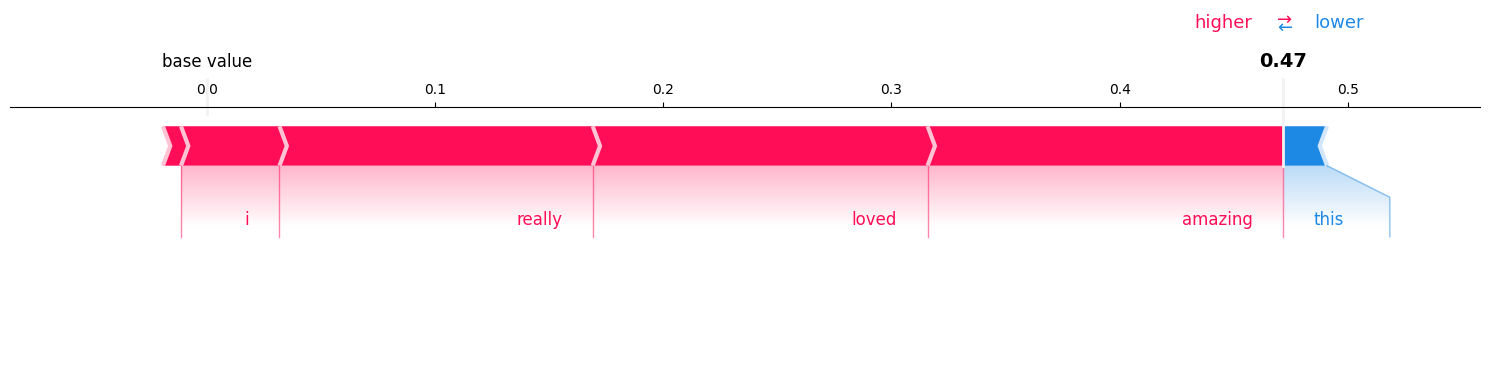

In [13]:
sv.plot_force(feature_names=token_names, abbreviate=False)

In [ ]:
approx_sii = shapiq.KernelSHAPIQ(
    n=game.n_players,
    index="k-SII",
    max_order=2,
    random_state=42,
)
sii = approx_sii.approximate(budget=50, game=game)

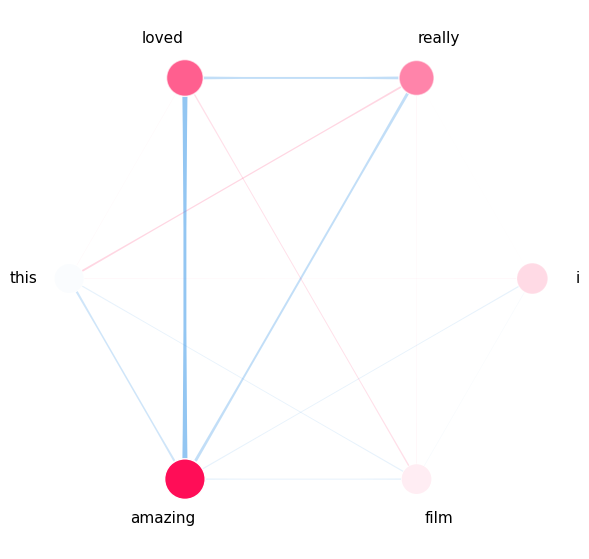

In [9]:
sii.plot_network(feature_names=token_names)


Negative Review Explained: "This movie was terrible and boring" 

In [37]:
game_neg = SentimentAnalysisLocalXAI(
    input_text="This movie was terrible and boring. I was very unhappy, flabbergasted and disappointed.",
    mask_strategy="mask",
    normalize=True,
)
# token_names_neg = game_neg.input_text.split()
token_names_neg = game_neg._tokenizer.convert_ids_to_tokens(game_neg._tokenized_input)
print(f"Tokens: {token_names_neg}")
print(f"Sentiment: {game_neg.grand_coalition_value:.3f}")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 28439.67it/s]


Tokens: ['this', 'movie', 'was', 'terrible', 'and', 'boring', '.', 'i', 'was', 'very', 'unhappy', ',', 'fl', '##ab', '##berg', '##ast', '##ed', 'and', 'disappointed', '.']
Sentiment: -1.606


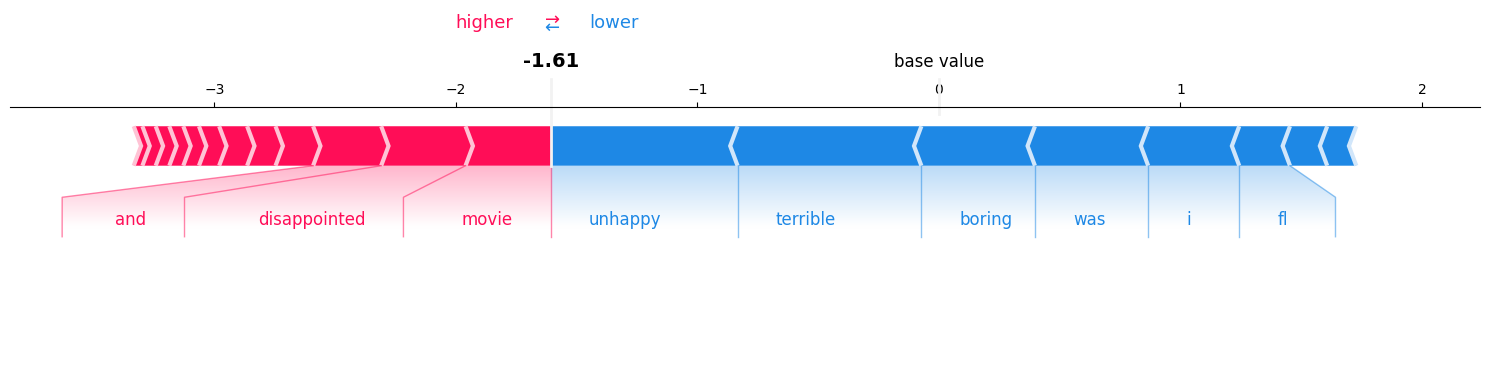

In [38]:
sv_neg = shapiq.KernelSHAP(n=game_neg.n_players, random_state=42).approximate(
    budget=50,
    game=game_neg,
)

sv_neg.plot_force(feature_names=token_names_neg, abbreviate=False)

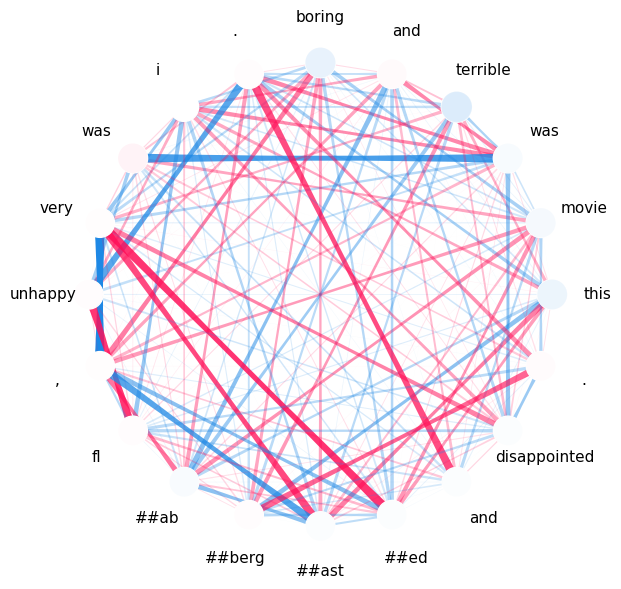

In [41]:
approx_sii = shapiq.KernelSHAPIQ(
    n=game_neg.n_players,
    index="k-SII",
    max_order=2,
    random_state=42,
)
sii = approx_sii.approximate(budget=50, game=game_neg)

sii.plot_network(feature_names=token_names_neg)


Sentence Plot

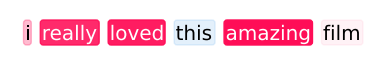

In [39]:
sv.plot_sentence(words=token_names)


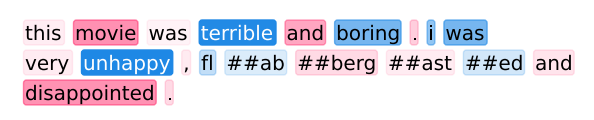

In [40]:
sv_neg.plot_sentence(words=token_names_neg)
